In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
# import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780385603.386633 1013002 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780385603.421978 1013002 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780385604.336904 1013002 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780385605.141784 1013002 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../../Cross Validation Data/test_data_small.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

94 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../../Cross Validation Data/test_data_small.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

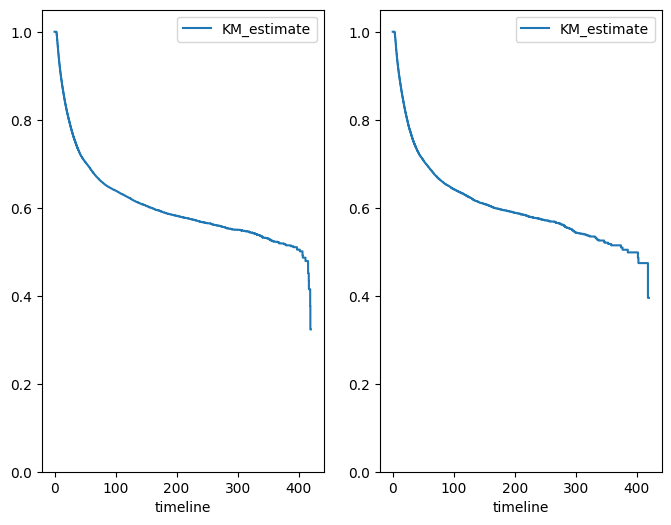

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

In [5]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

# Mixture Weibull Model

In [8]:
def build_mixture_weibull_model( ridge_penalty = 1e-4, lasso_penalty = 1e-4 ):
    lambda_max = 40.0
    
    def softplus_inv(y):
        return tf.math.log(tf.math.exp(y) - 1)
        
    def scaled_sigmoid_link(x):
        '''
            Smoothly bounds the neural network output between 0 and lambda_max.
        '''
        return lambda_max * tf.math.sigmoid(x)
    
    def scaled_sigmoid_link_inv(y):
        '''
            The inverse of the scaled sigmoid (the scaled logit function).
            Includes epsilon clipping for numerical stability.
        '''
        # Normalize the value back to the (0, 1) range
        u = y / lambda_max
        # Clip u to be strictly between 0 and 1 to avoid log(0) or division by zero
        u = tf.clip_by_value(u, 1.0e-7, 1.0 - 1.0e-7)
        # Apply the logit transformation
        return -( tf.math.log(1.0 - u) - tf.math.log(u) )

    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
    
    # Shape parameter: constant
    # Scale parameter: neural network
    # Cure probability: neural network
    mixture_weibull_parameters = {
        # "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0, "warmup_time": 0},
        "k": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        "lam": {"link": scaled_sigmoid_link, "link_inv": scaled_sigmoid_link_inv, "par_type": "nn", "shape": 1, "init": 1.0, "warmup_time": 0},
        "p": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        X, y, delta = data
        
        # k = model.get_variable("k")
        k = model.get_variable("k", nn_output)
        lam = model.get_variable("lam", nn_output)
        p = model.get_variable("p", nn_output)

        log_y = tf.math.log(y + 1.0e-7)
        log_lam = tf.math.log(lam + 1.0e-7)
        log_S0 = -( y / (lam + 1.0e-7) )**k 
        S0 = tf.math.exp( log_S0 )
        
        log_f0 = tf.math.log(k + 1.0e-7) - k * log_lam + (k - 1.0) * log_y + log_S0
        
        loglik_terms = delta * (tf.math.log(1.0 - p + 1.0e-7) + log_f0) + \
                       (1.0 - delta) * tf.math.log(p + (1.0 - p)*S0 + 1.0e-7)
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    def neural_network(model, input_dim=100, seed=None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)
        
        elastic_net = tf.keras.regularizers.L1L2(l1 = lasso_penalty, l2 = ridge_penalty)
        
        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 3,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return mixture_weibull_parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [9]:
with tf.device("/GPU:0"):
    mixture_weibull_parameters, mixture_weibull_loss, mixture_weibull_neural_network, mixture_weibull_call, mixture_weibull_call_nolast = \
    build_mixture_weibull_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
    seed = 10
    mixture_weibull_model = thf.ModelNN(mixture_weibull_parameters, mixture_weibull_loss,
                                        mixture_weibull_neural_network, mixture_weibull_call,
                                        mixture_weibull_call_nolast, input_dim = (n_features,), seed = seed)
    mixture_weibull_model.pre_train_model(epochs = None, x = X_train, data = data_train, shuffle = True)
    mixture_weibull_model.train_model(epochs = 1200, x = X_train, data = data_train,
                                      shuffle = True,
                                      get_covariances = True,
                                      validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                      force_training_validation = False,
                                      optimizer_independent = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                      optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                      fine_tune_nn_lr = 0.005, fine_tune_independent_lr = 0.005,
                                      early_stopping = True, early_stopping_patience = 30, 
                                      early_stopping_warmup = 10,
                                      reduce_lr = True, reduce_lr_warmup = 0,
                                      reduce_lr_factor = 0.5, reduce_lr_min_delta = 500, reduce_lr_patience = 25,
                                      reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                      fine_tune = True,
                                      finetune_early_stopping = True, finetune_early_stopping_patience = 30,
                                      finetune_early_stopping_warmup = 10,
                                      finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                      finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 5, finetune_reduce_lr_patience = 25,
                                      finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                      deterministic = True,
                                      verbose = True, print_freq = 1,
                                      train_batch_size = None, val_batch_size = None,
                                      buffer_size = None, gradient_accumulation_steps = None)

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 72 / 1200 ]  | Loss:  32273.2793 | Best Loss:  32144.5117 | Speed:  18  epoch/s    | Elapsed Time:  3.79545283  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 663 / 1200 ]  | Loss:  127938.328 | Best Loss:  127940.062 | Speed:  48  epoch/s    | Elapsed Time:  13.7367105  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 24.096 seconds.


I0000 00:00:1780385654.969051 1013002 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x5a15ec411c90


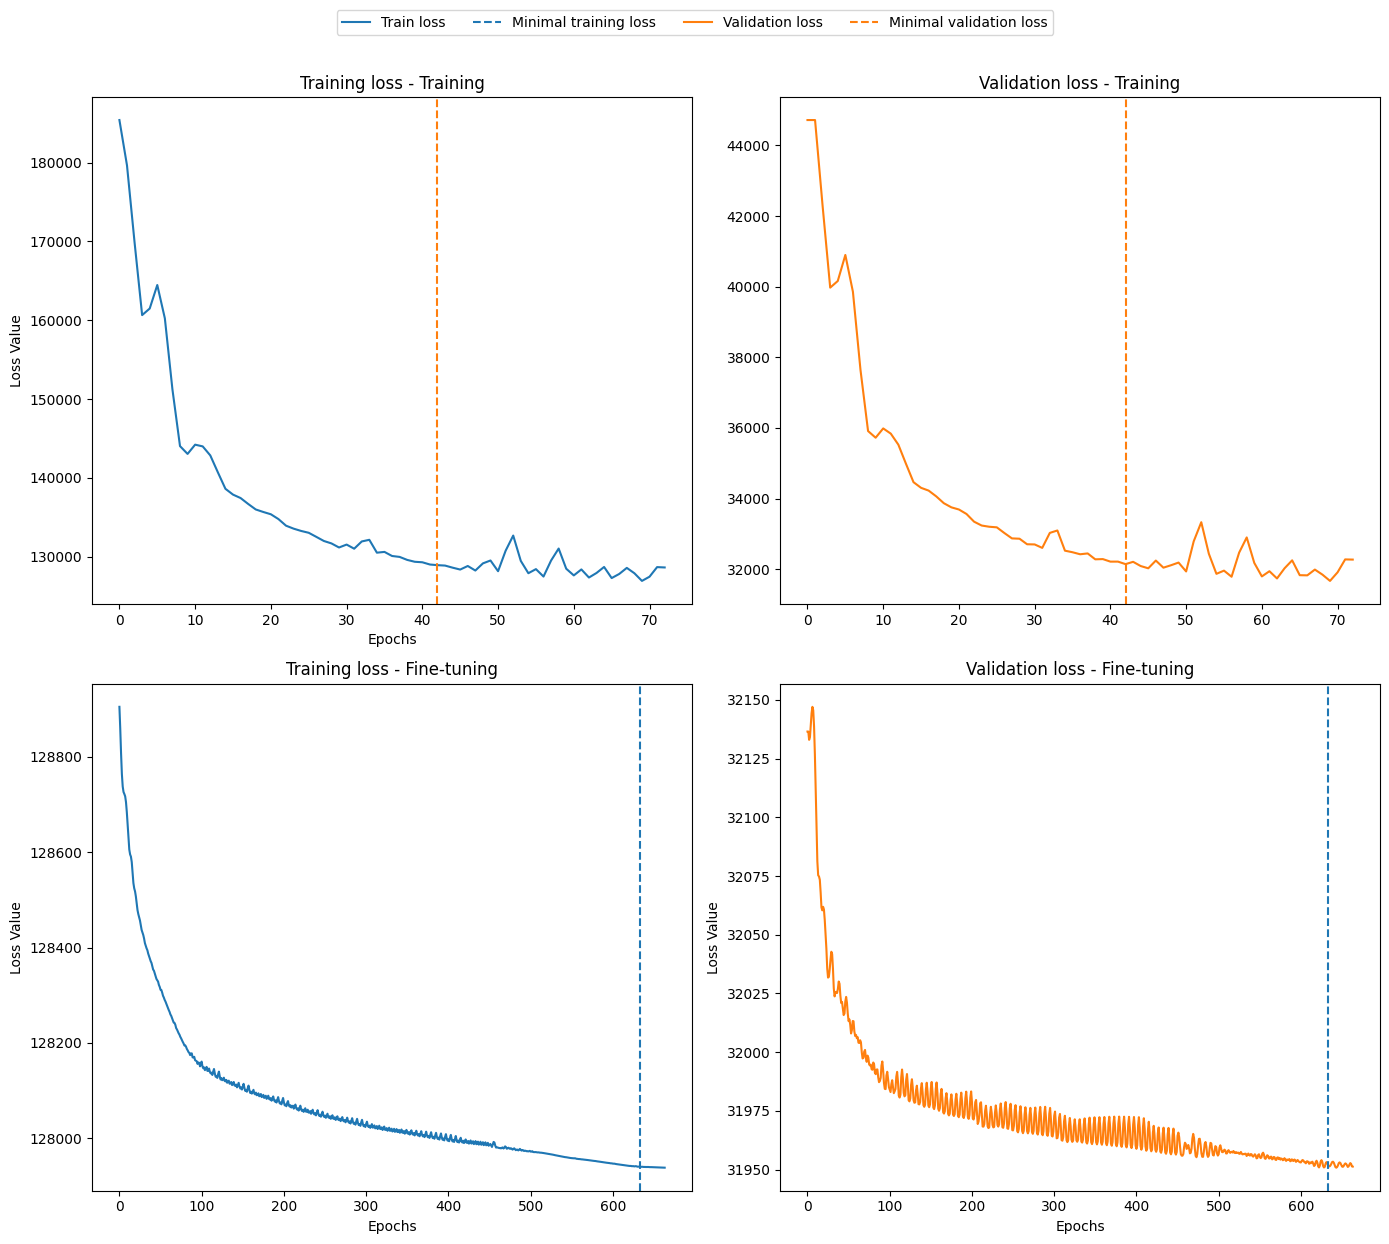

In [10]:
utils.plot_model_convergence( mixture_weibull_model )

In [11]:
pars_train = mixture_weibull_model.predict(X_train)
pars_test = mixture_weibull_model.predict(X_test)

# k_train = mixture_weibull_model.predict("k")
# k_test = k_train.copy()
k_train = pars_train["k"].numpy().flatten()
k_test = pars_test["k"].numpy().flatten()

lam_train = pars_train["lam"].numpy().flatten()
p_train = pars_train["p"].numpy().flatten()
lam_test = pars_test["lam"].numpy().flatten()
p_test = pars_test["p"].numpy().flatten()

ts_grid_max = np.max(np.concatenate([y_train, y_test]))
ts_grid = np.linspace(0.0001 , ts_grid_max, 100)[:,None]
S_ts_train = p_train + (1-p_train) * np.exp( -(ts_grid / lam_train)**k_train )
S_ts_test = p_test + (1-p_test) * np.exp( -(ts_grid / lam_test)**k_test )

S_train = p_train + (1-p_train)*np.exp( -(y_train / lam_train)**k_train )
S_test = p_test + (1-p_test)*np.exp( -(y_test / lam_test)**k_test )
H_train = -np.log( S_train )
H_test = -np.log( S_test )

expected_time_lived_train = np.trapezoid(S_ts_train, x = ts_grid.flatten(), axis = 0)
expected_time_lived_test = np.trapezoid(S_ts_test, x = ts_grid.flatten(), axis = 0)

# Lower expected time = higher risk (these are NEGATIVE numbers)
risk_score_train = -expected_time_lived_train
risk_score_test = -expected_time_lived_test

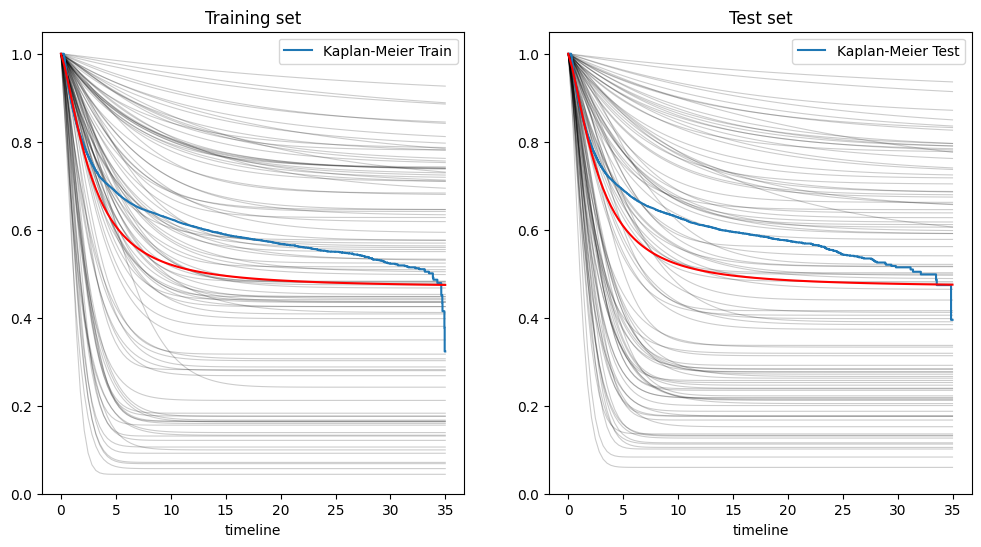

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
utils.average_kaplan_meier(ts_grid,
                           S_ts_train, S_ts_test,
                           y_train, delta_train, y_test, delta_test, show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()